# Results Notebook

This notebook is reserved for:
- Model training results
- Performance metrics
- Confusion matrices
- ROC curves
- Feature importance analysis
- Final figures for the report

## Current Data Status

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import numpy as np
import pandas as pd
from collections import Counter

# Load features
data = np.load('../data/03_processed/features.npz', allow_pickle=True)
X = data['X']
y = data['y']
subject = data['subject']
feature_names = list(data['feature_names'])

In [2]:
print("=== DATASET SUMMARY ===\n")
print(f"Features: {X.shape[0]:,} samples × {X.shape[1]} features")
print(f"Labels: {len(np.unique(y))} classes ({sorted(set(y))})")
print(f"Subjects: {len(set(subject))}")
print()
print("Label distribution:", dict(Counter(y)))
print()
print("Subject distribution:", dict(Counter(subject)))

=== DATASET SUMMARY ===

Features: 132,474 samples × 51 features
Labels: 3 classes ([np.int64(1), np.int64(2), np.int64(3)])
Subjects: 15

Label distribution: {np.int64(1): 70310, np.int64(2): 39864, np.int64(3): 22300}

Subject distribution: {np.int64(2): 8484, np.int64(3): 8620, np.int64(4): 8660, np.int64(5): 8868, np.int64(6): 8808, np.int64(7): 8792, np.int64(8): 8836, np.int64(9): 8788, np.int64(10): 9108, np.int64(11): 8912, np.int64(13): 8904, np.int64(14): 8774, np.int64(15): 8932, np.int64(16): 8884, np.int64(17): 9104}


In [3]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

from src.models import (
    get_backend_status,
    get_torch_status,
    get_enhanced_models,
    evaluate_feature_configs_loso,
    run_loso_cv,
    summarize_selected_features,
    compute_metrics_table,
    save_metrics_json,
)

# Output paths
FIGURES_DIR = Path('../experiments/run_001/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_PATH = Path('../experiments/run_001/metrics.json')

backend_status = get_backend_status()
torch_status = get_torch_status()
print("Imports ready. Figures path:", FIGURES_DIR.resolve())
print("Backend status:", backend_status)
print("Torch status:", torch_status)

Imports ready. Figures path: /home/fjg/raspnas/personal/education/university/courses/third_year/healthcare/final_project/wesad-wrist-stress-prediction/experiments/run_001/figures
Backend status: {'cuml_available': True, 'auto_backend': 'gpu', 'cuml_import_error': ''}
Torch status: {'torch_available': True, 'cuda_available': True, 'default_device': 'cuda', 'torch_import_error': ''}


## LOSO Cross-Validation with Feature Engineering Search

Since model scores are close, we first search feature pipelines under LOSO using a probe model, then train all models with the best feature configuration.

Candidate feature strategies include:
- Univariate selection
- Variance filtering + correlation pruning
- Optional PCA compression
- Fold-safe fitting to avoid leakage

In [4]:
# LOSO training with feature-engineering search + stronger models

subjects = sorted(np.unique(subject))
print(f"Subjects for LOSO: {subjects}")

requested_backend = "gpu"
run_lstm = True

try:
    models = get_enhanced_models(random_state=42, backend=requested_backend)
    print("Using backend:", requested_backend)
except ImportError as exc:
    print("GPU backend unavailable, falling back to CPU.")
    print("Reason:", exc)
    requested_backend = "cpu"
    models = get_enhanced_models(random_state=42, backend=requested_backend)

print(f"Tabular models: {list(models.keys())}")

feature_configs = [
    {
        "name": "k24_fclassif",
        "scaler": "robust",
        "selection_k": 24,
        "selection_method": "f_classif",
    },
    {
        "name": "var_corr_k24_fclassif",
        "scaler": "robust",
        "variance_threshold": 1e-4,
        "correlation_threshold": 0.95,
        "selection_k": 24,
        "selection_method": "f_classif",
    },
    {
        "name": "var_corr_k20_mi",
        "scaler": "robust",
        "variance_threshold": 1e-4,
        "correlation_threshold": 0.95,
        "selection_k": 20,
        "selection_method": "mutual_info",
    },
    {
        "name": "var_corr_k24_pca98",
        "scaler": "robust",
        "variance_threshold": 1e-4,
        "correlation_threshold": 0.95,
        "selection_k": 24,
        "selection_method": "f_classif",
        "pca_variance": 0.98,
    },
]

probe_model_name = "Logistic Regression Tuned"
probe_model = models[probe_model_name]

print("\nSearching best feature configuration...")
feature_search_df = evaluate_feature_configs_loso(
    X=X,
    y=y,
    subject=subject,
    probe_model=probe_model,
    configs=feature_configs,
    backend=requested_backend,
    show_progress=True,
)

display(feature_search_df[["config_name", "Accuracy", "Precision", "Recall", "F1-Score", "mean_selected_features"]])

if feature_search_df.empty:
    raise RuntimeError("Feature search returned no valid configuration.")

best_config_name = feature_search_df.iloc[0]["config_name"]
best_config = None
for cfg in feature_configs:
    if cfg["name"] == best_config_name:
        best_config = {k: v for k, v in cfg.items() if k != "name"}
        break

if best_config is None:
    raise RuntimeError("Best feature config could not be resolved.")

print(f"\nBest feature config: {best_config_name}")
print(best_config)

lstm_config = {
    "sequence_length": 8,
    "stride": 1,
    "hidden_size": 96,
    "num_layers": 2,
    "dropout": 0.2,
    "epochs": 8,
    "batch_size": 256,
    "learning_rate": 1e-3,
    "device": "auto",
    "random_state": 42,
}

results = run_loso_cv(
    X=X,
    y=y,
    subject=subject,
    models=models,
    show_progress=True,
    backend=requested_backend,
    feature_pipeline_config=best_config,
    include_lstm=(run_lstm and torch_status["torch_available"]),
    lstm_config=lstm_config,
)

if "LSTM" in results:
    print("LSTM added to evaluation.")
else:
    print("LSTM skipped (PyTorch unavailable or no valid sequence folds).")

feature_summary_df = summarize_selected_features(results, feature_names, top_n=20)
print("\nTop selected features across folds:")
display(feature_summary_df)

print("\nLOSO training complete.")

Subjects for LOSO: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17)]
Using backend: gpu
Tabular models: ['MLP']


KeyError: 'Logistic Regression Tuned'

In [ ]:
# Compute Metrics

metrics_df = compute_metrics_table(results)

for _, row in metrics_df.iterrows():
    print(f"=== {row['Model']} ===")
    print(f"Accuracy:  {row['Accuracy']:.4f}")
    print(f"Precision: {row['Precision']:.4f}")
    print(f"Recall:    {row['Recall']:.4f}")
    print(f"F1-Score:  {row['F1-Score']:.4f}")
    print()

save_metrics_json(metrics_df, METRICS_PATH)
print(f"Saved metrics to: {METRICS_PATH}")

display(metrics_df)

=== SVM ===
Accuracy:  0.6813
Precision: 0.6687
Recall:    0.6813
F1-Score:  0.6733

=== SVM Tuned ===
Accuracy:  0.6755
Precision: 0.6599
Recall:    0.6755
F1-Score:  0.6645

=== Logistic Regression ===
Accuracy:  0.6300
Precision: 0.5818
Recall:    0.6300
F1-Score:  0.5991

=== Logistic Regression Tuned ===
Accuracy:  0.6302
Precision: 0.5823
Recall:    0.6302
F1-Score:  0.5994

=== MLP ===
Accuracy:  0.6974
Precision: 0.6893
Recall:    0.6974
F1-Score:  0.6925

=== LSTM ===
Accuracy:  0.6953
Precision: 0.6873
Recall:    0.6953
F1-Score:  0.6904

Saved metrics to: ../experiments/run_001/metrics.json


,Model,Accuracy,Precision,Recall,F1-Score
0,SVM,0.681258,0.668683,0.681258,0.673310
1,SVM Tuned,0.675544,0.659931,0.675544,0.664504
2,Logistic Regression,0.630041,0.581783,0.630041,0.599058
3,Logistic Regression Tuned,0.630214,0.582264,0.630214,0.599358
4,MLP,0.697390,0.689269,0.697390,0.692544
5,LSTM,0.695261,0.687328,0.695261,0.690434


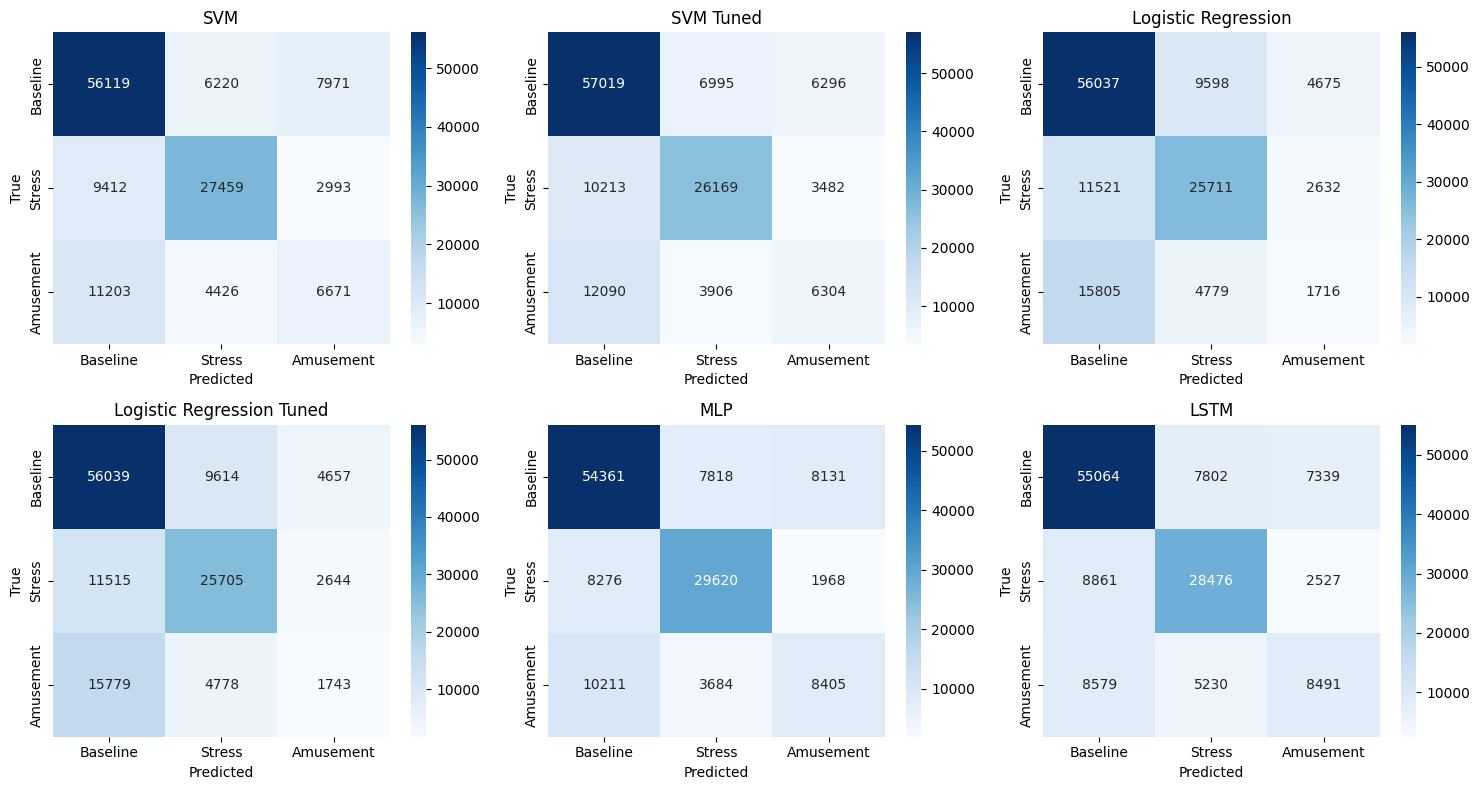

In [ ]:
# Confusion Matrices

label_names = {1: "Baseline", 2: "Stress", 3: "Amusement"}
labels_sorted = sorted(np.unique(y).tolist())

model_names = [
    name for name, out in results.items()
    if isinstance(out, dict) and len(out.get("y_true", [])) > 0
]

n_models = len(model_names)
n_cols = min(3, max(1, n_models))
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes, dtype=object).reshape(-1)

for ax, name in zip(axes, model_names):
    y_true = np.array(results[name]["y_true"])
    y_pred = np.array(results[name]["y_pred"])
    cm = confusion_matrix(y_true, y_pred, labels=labels_sorted)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=[label_names.get(l, str(l)) for l in labels_sorted],
        yticklabels=[label_names.get(l, str(l)) for l in labels_sorted],
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

for ax in axes[n_models:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("../experiments/run_001/figures/confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

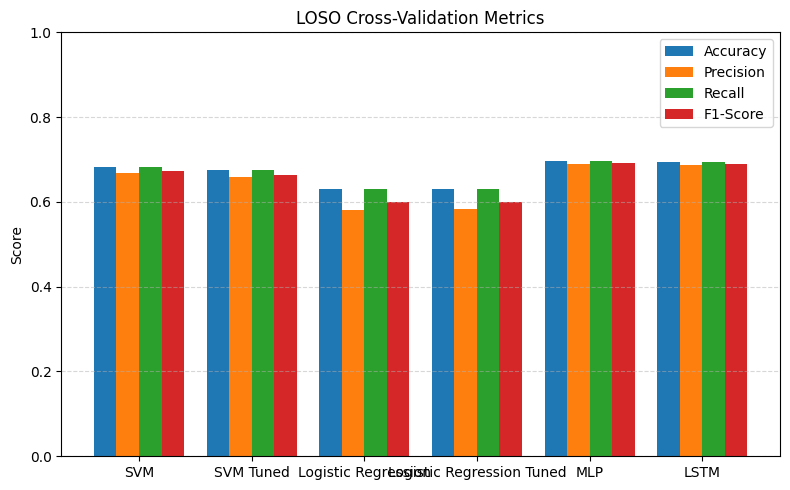

In [ ]:
# Metrics Bar Plot

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(metrics_df))
width = 0.2

ax.bar(x - 1.5*width, metrics_df["Accuracy"], width, label="Accuracy")
ax.bar(x - 0.5*width, metrics_df["Precision"], width, label="Precision")
ax.bar(x + 0.5*width, metrics_df["Recall"], width, label="Recall")
ax.bar(x + 1.5*width, metrics_df["F1-Score"], width, label="F1-Score")

ax.set_ylabel("Score")
ax.set_title("LOSO Cross-Validation Metrics")
ax.set_xticks(x)
ax.set_xticklabels(metrics_df["Model"])
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("../experiments/run_001/figures/metrics_barplot.png", dpi=300, bbox_inches="tight")
plt.show()


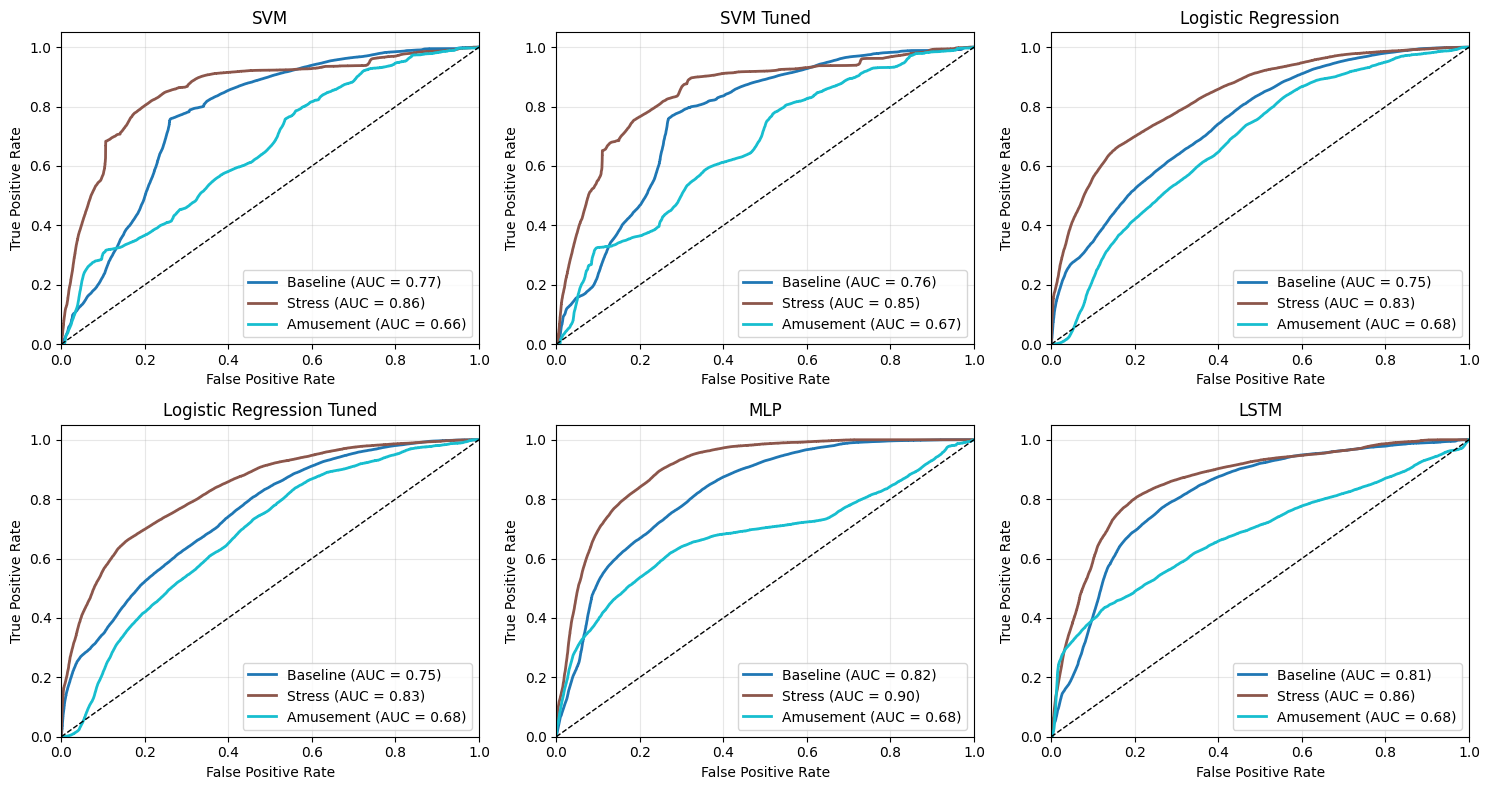

In [ ]:
# ROC Curves (One-vs-Rest)

labels_sorted = sorted(np.unique(y).tolist())
label_names = {1: "Baseline", 2: "Stress", 3: "Amusement"}

model_names_prob = [
    name for name, out in results.items()
    if isinstance(out, dict) and len(out.get("y_prob", [])) > 0
]

n_models = len(model_names_prob)
n_cols = min(3, max(1, n_models))
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes, dtype=object).reshape(-1)

palette = plt.cm.tab10(np.linspace(0, 1, len(labels_sorted)))

for ax, name in zip(axes, model_names_prob):
    y_true = np.array(results[name]["y_true"])
    y_prob_all = np.vstack(results[name]["y_prob"])

    for i, label in enumerate(labels_sorted):
        y_true_bin = (y_true == label).astype(int)
        if len(np.unique(y_true_bin)) < 2:
            continue

        fpr, tpr, _ = roc_curve(y_true_bin, y_prob_all[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(
            fpr,
            tpr,
            color=palette[i],
            lw=2,
            label=f"{label_names.get(label, str(label))} (AUC = {roc_auc:.2f})",
        )

    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(name)
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)

for ax in axes[n_models:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("../experiments/run_001/figures/roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()

## Binary Classification (Stress vs. Non-Stress)

Collapse Baseline (1) and Amusement (3) into "non-stress" vs. Stress (2).

In [ ]:
from src.evaluation import compute_binary_metrics

print("=== Binary Classification (Stress vs. Non-Stress) ===\n")

binary_records = []
for model_name, result in results.items():
    yt = np.array(result["y_true"])
    yp = np.array(result["y_pred"])
    bm = compute_binary_metrics(yt, yp, positive_label=2)
    bm["model"] = model_name
    binary_records.append(bm)

binary_df = pd.DataFrame(binary_records)
display(binary_df[[
    "model", "binary_accuracy", "binary_f1", "binary_precision",
    "binary_recall", "binary_specificity"
]].round(4))

In [ ]:
# Binary confusion matrices
n_models = len(results)
n_cols = min(3, max(1, n_models))
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes, dtype=object).reshape(-1)

for ax, (model_name, result) in zip(axes, results.items()):
    yt = np.array(result["y_true"])
    yp = np.array(result["y_pred"])
    yt_bin = (yt == 2).astype(int)
    yp_bin = (yp == 2).astype(int)
    cm = confusion_matrix(yt_bin, yp_bin, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Non-Stress", "Stress"],
                yticklabels=["Non-Stress", "Stress"])
    ax.set_title(f"{model_name} (Binary)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

for ax in axes[n_models:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("../experiments/run_001/figures/confusion_matrices_binary.png", dpi=300, bbox_inches="tight")
plt.show()

## Per-Subject Performance Breakdown

Evaluating how well each model generalizes to individual subjects.

In [ ]:
from src.evaluation import compute_per_subject_metrics

for model_name, result in results.items():
    yt = np.array(result["y_true"])
    yp = np.array(result["y_pred"])
    subj = np.array(result["subject"])
    ps_df = compute_per_subject_metrics(yt, yp, subj)
    print(f"\n=== {model_name} — Per-Subject Accuracy ===")
    display(ps_df[["subject", "accuracy", "f1", "support"]].round(4))
    print(f"Mean: {ps_df['accuracy'].mean():.3f} ± {ps_df['accuracy'].std():.3f}")

In [ ]:
# Per-subject accuracy bar plot for best model
best_model = metrics_df.iloc[0]["Model"]
result = results[best_model]
ps_df = compute_per_subject_metrics(
    np.array(result["y_true"]),
    np.array(result["y_pred"]),
    np.array(result["subject"]),
)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2ecc71' if acc >= 0.6 else '#e74c3c' for acc in ps_df['accuracy']]
ax.bar(ps_df['subject'].astype(str), ps_df['accuracy'], color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(y=ps_df['accuracy'].mean(), color='blue', linestyle='--', label=f"Mean: {ps_df['accuracy'].mean():.3f}")
ax.set_xlabel("Subject")
ax.set_ylabel("Accuracy")
ax.set_title(f"Per-Subject Accuracy — {best_model}")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("../experiments/run_001/figures/per_subject_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()